/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV02 경로

In [88]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
import matplotlib.pyplot as plt

# 경로 설정 (본인의 실제 경로로 수정)
BASE_PATH = "/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV02"
person_file = "person.png" # 혹은 jpg
cat_file = "cat.jpg"
bg_file = "sand.png"

# 파일 존재 여부 확인 (에러 방지)
for f in [person_file, cat_file, bg_file]:
    path = os.path.join(BASE_PATH, f)
    print(f"Checking {f}: {'파일 존재' if os.path.exists(path) else '파일 없음'}")

Checking person.png: 파일 존재
Checking cat.jpg: 파일 존재
Checking sand.png: 파일 존재


In [89]:
def load_and_show(file_name):
    path = os.path.join(BASE_PATH, file_name)
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

# 1. 인물 이미지 로드
img_p = load_and_show(person_file)

# 2. 모델용 전처리 정의
preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)), # 모델 입력 크기
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"이미지 준비 완료: {img_p.shape}")

이미지 준비 완료: (450, 800, 3)


- **사람을 감지해보자.**

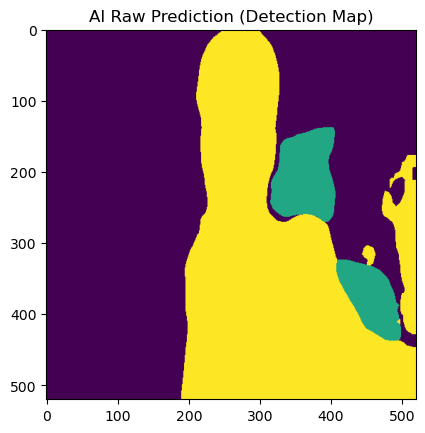

In [90]:
# 모델 로드
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()

# 추론 실행
input_tensor = preprocess(img_p).unsqueeze(0)
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    preds = output.argmax(0).byte().cpu().numpy()

# AI가 찾은 클래스들 확인 (인물은 15번)
plt.imshow(preds)
plt.title("AI Raw Prediction (Detection Map)")
plt.show()

- **주변에 뭔가가 초록색으로 감지되었는데 찾아보니 학습한 데이터안의 다른 사물로 자동 분류된 것이라고 한다.**
- **인물 클래스만 추출해보자**

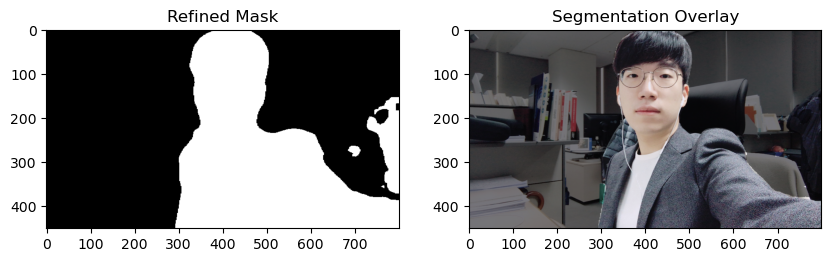

In [91]:
# 인물(15) 클래스만 추출
mask_p = (preds == 15).astype(np.uint8) * 255

# 원본 크기로 리사이즈 (가장 중요한 부분)
mask_p_resized = cv2.resize(mask_p, (img_p.shape[1], img_p.shape[0]), interpolation=cv2.INTER_NEAREST)

# 마스크가 인물에 잘 씌워졌는지 '랜드마크'처럼 확인
overlay = img_p.copy()
overlay[mask_p_resized == 0] = overlay[mask_p_resized == 0] // 2 # 배경을 어둡게

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(mask_p_resized, cmap='gray'); plt.title("Refined Mask")
plt.subplot(1, 2, 2); plt.imshow(overlay); plt.title("Segmentation Overlay")
plt.show()

- **인물 클래스만 추출을 시도했는데 다른 것들도 추출이 되는 문제점을 발견했다.**

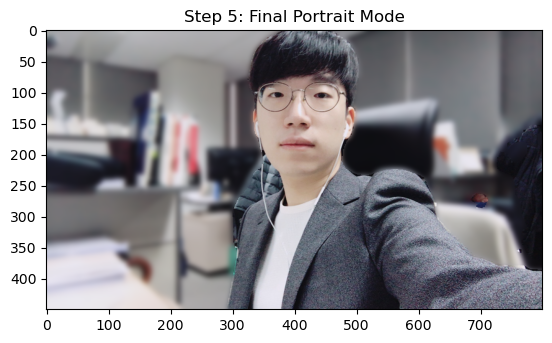

In [92]:
# 1. 전체 이미지 블러 처리
img_p_blur = cv2.GaussianBlur(img_p, (25, 25), 0)

# 3채널 마스크 생성
mask_p_3ch = cv2.cvtColor(mask_p_resized, cv2.COLOR_GRAY2RGB)

# 2. 합성 (마스크가 흰색이면 원본, 검은색이면 블러 배경)
portrait_p = np.where(mask_p_3ch == 255, img_p, img_p_blur)

plt.imshow(portrait_p)
plt.title("Step 5: Final Portrait Mode")
plt.show()

-**인물 추출과 블러 처리가 완벽하지 않은 문제점을 발견했다.**
-**예제에 있는 사진을 가지고와서 작업한 내용이기에 예제에 있는 사진을 다시 가져와서 문제점을 찾아보자.
블러처리등 살짝 다른 부분이 있지만 거의 차이가 없기에 그냥 예제의 이미지를 불러오도록 하겠다.**

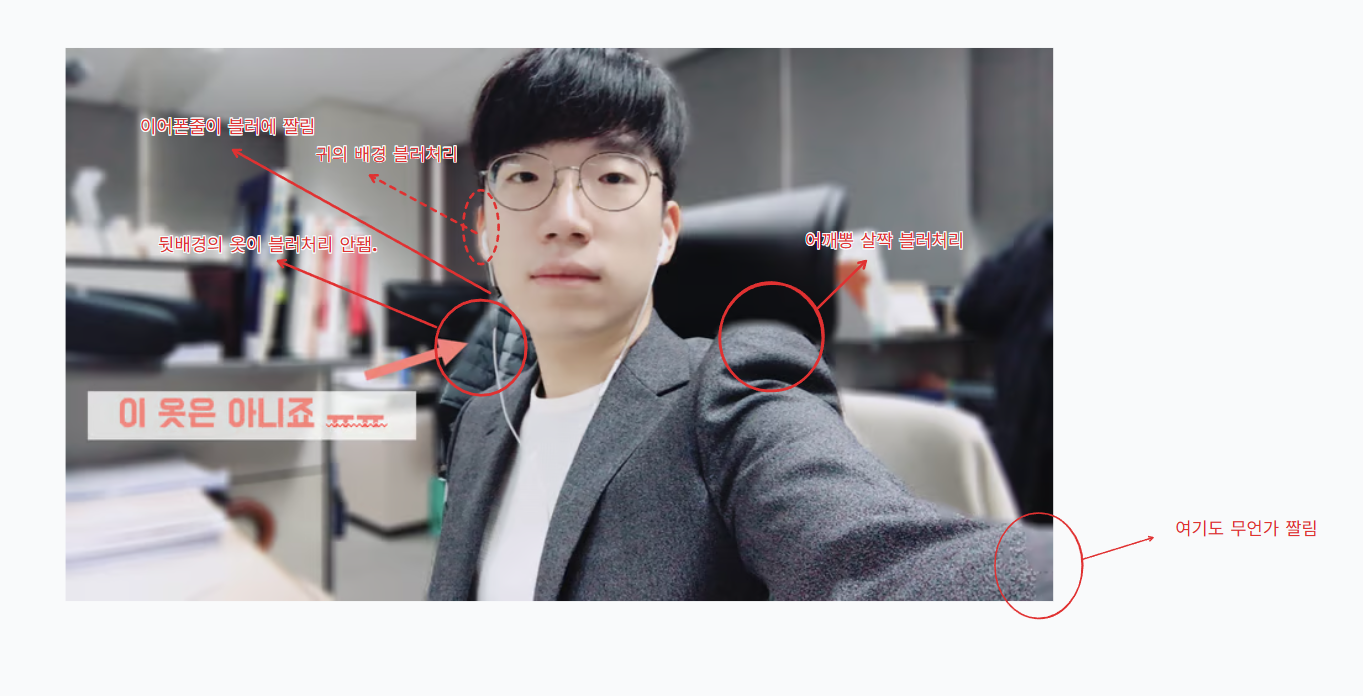

In [42]:
from PIL import Image
Image.open('image(2).png')

- **해당 이미지는 예제의 이미지이고 팀원들과 함께 찾은 문제점들이다.**
- **이런 문제를 해결하기 위해서 어떤 방법을 사용해야할지를 고민해봤다.**
- **문제점들을 정리한 후 ai에게 물어보았다. 어떻게 해결해야할까? 이런 부분들을 해결해 주는 기술이 현재 뭐가 있을까?**

1. 개별 개체를 구분하는 'Instance Segmentation' 도입
문제점 해결: 사람과 겹쳐진 사물이나 엉뚱한 덩어리가 딸려오는 문제
우리가 쓴 Semantic Segmentation은 "이 구역은 사람이야"라고만 말합니다. 반면 Instance Segmentation은 "이건 '사람 A'이고, 그 옆의 덩어리는 '의자 B'야"라고 객체별로 신분증을 달아줍니다.
솔루션: Mask R-CNN이나 최근의 Mask2Former 같은 모델을 사용합니다.
이유: 단순히 '클래스'만 나누는 게 아니라, 사물의 **경계(Bounding Box)**를 먼저 찾고 그 안에서 마스크를 생성하기 때문에, 사람 옆에 딱 붙어 있는 엉뚱한 사물이 마스크에 포함될 확률을 획기적으로 낮출 수 있습니다.

2. 0과 1 사이의 디테일, 'Image Matting' 기법
문제점 해결: 이어폰, 액세서리 소실 및 머리카락 뭉개짐
지금 우리가 만든 마스크는 0(검정) 아니면 255(흰색)뿐인 '이진 마스크'입니다. 하지만 이어폰 줄이나 머리카락은 픽셀 하나에 배경과 물체가 섞여 있죠.
솔루션: Deep Image Matting 또는 MODNet 같은 매팅 전용 모델을 도입합니다.
이유: 이 모델들은 0과 1 사이의 투명도(Alpha) 값을 계산합니다. 이어폰 같은 미세한 액세서리는 '반투명'하게 처리하여 배경과 자연스럽게 블렌딩(Blending)함으로써, 블러 처리가 되더라도 형태가 완전히 뭉개지지 않고 디테일을 유지할 수 있게 해줍니다.

3. 맥락을 이해하는 'Segment Anything Model (SAM)' 활용
문제점 해결: 몸이 일부만 나왔을 때 배경으로 오인하는 문제
현재 모델은 '완전한 사람의 형태'를 기대하지만, 실제로는 팔만 보이거나 상체만 보일 때가 많죠. 이건 모델이 전체적인 **맥락(Context)**을 파악하는 능력이 부족하기 때문입니다.
솔루션: Meta에서 공개한 **SAM(Segment Anything Model)**을 활용하거나 SegFormer 같은 트랜스포머 기반 모델을 사용합니다.
이유: SAM은 "이 점이나 박스가 포함된 물체를 다 찾아줘"라는 힌트(Prompt)를 주면, 몸의 일부만 보여도 그 픽셀들이 하나의 유기적인 물체임을 이해합니다. 또한 트랜스포머 구조는 이미지의 국소적인 부분뿐만 아니라 전체적인 관계를 보기 때문에, 가려진 몸 부분도 '사람의 일부'라고 훨씬 더 똑똑하게 판단합니다.

# 1: Mask R-CNN (인스턴스 세그멘테이션) :사람과 사물이 겹쳐 있을 때 사람만 정확히 골라내기**

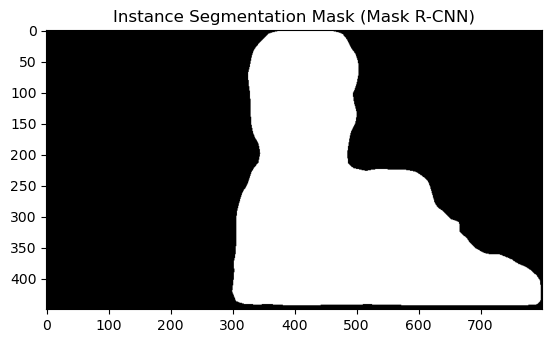

In [93]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. 모델 로드 (인스턴스 세그멘테이션용)
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = maskrcnn_resnet50_fpn(weights=weights).eval()

def test_instance_segmentation(img_rgb):
    transform = torchvision.transforms.ToTensor()
    input_tensor = transform(img_rgb).unsqueeze(0)
    
    with torch.no_grad():
        prediction = model(input_tensor)[0]
    
    # 2. 결과 필터링 (사람 ID는 1번, 확률 0.8 이상인 것만)
    # Mask R-CNN은 COCO 데이터셋을 써서 사람 ID가 1번입니다!
    person_indices = [i for i, label in enumerate(prediction['labels']) if label == 1 and prediction['scores'][i] > 0.8]
    
    if not person_indices:
        print("사람을 찾지 못했습니다.")
        return img_rgb
    
    # 가장 점수가 높은 사람 한 명의 마스크만 선택
    best_idx = person_indices[0]
    mask = prediction['masks'][best_idx, 0].mul(255).byte().cpu().numpy()
    
    # 3. 마스크 이진화 (Threshold)
    _, mask_binary = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
    
    return mask_binary

# 테스트 실행
mask_instance = test_instance_segmentation(img_p)
plt.imshow(mask_instance, cmap='gray')
plt.title("Instance Segmentation Mask (Mask R-CNN)")
plt.show()

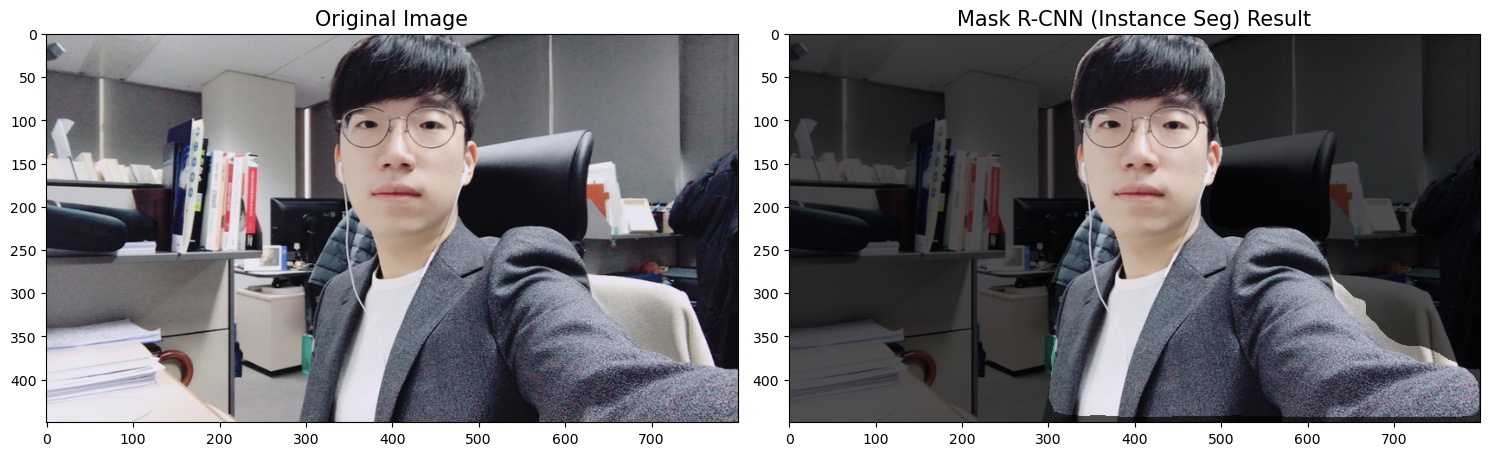

 분석 포인트: 이전 DeepLabV3에서 나타났던 '옆의 엉뚱한 덩어리'가 사라졌는지 확인


In [94]:
# 실습 1 실행 및 시각화
mask_instance = test_instance_segmentation(img_p)

# 결과 출력
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_p)
plt.title("Original Image", fontsize=15)

plt.subplot(1, 2, 2)
# 마스크가 씌워진 부분만 밝게 강조해서 보여주기
overlay_instance = img_p.copy()
overlay_instance[mask_instance == 0] = overlay_instance[mask_instance == 0] // 3
plt.imshow(overlay_instance)
plt.title("Mask R-CNN (Instance Seg) Result", fontsize=15)

plt.tight_layout()
plt.show()

print(" 분석 포인트: 이전 DeepLabV3에서 나타났던 '옆의 엉뚱한 덩어리'가 사라졌는지 확인")

- **여전히 완벽하게 분리하지 못했다. 사람의 일부분을 감지하지 못하는 문제도 여전히 있다.**

# 2: MODNet (Image Matting) :이어폰 줄, 머리카락 등 미세한 액세서리 살리기

In [95]:
# (개념적 코드 - 실제 실행을 위해선 MODNet 가중치 파일이 필요합니다)
# 1. 마스크가 아닌 'Alpha'를 추출합니다.
# alpha = modnet_model(input_tensor) 

def apply_matting_blur(img, alpha):
    # alpha는 0~1 사이의 값을 가진 행렬입니다.
    # 배경을 블러 처리합니다.
    background_blur = cv2.GaussianBlur(img, (25, 25), 0)
    
    # 합성 공식: (원본 * alpha) + (배경 * (1 - alpha))
    # 이 공식을 통해 이어폰 줄 같은 미세한 부분이 '반투명'하게 살아납니다.
    alpha = alpha[:, :, np.newaxis] # 채널 맞추기
    result = (img * alpha + background_blur * (1 - alpha)).astype(np.uint8)
    return result

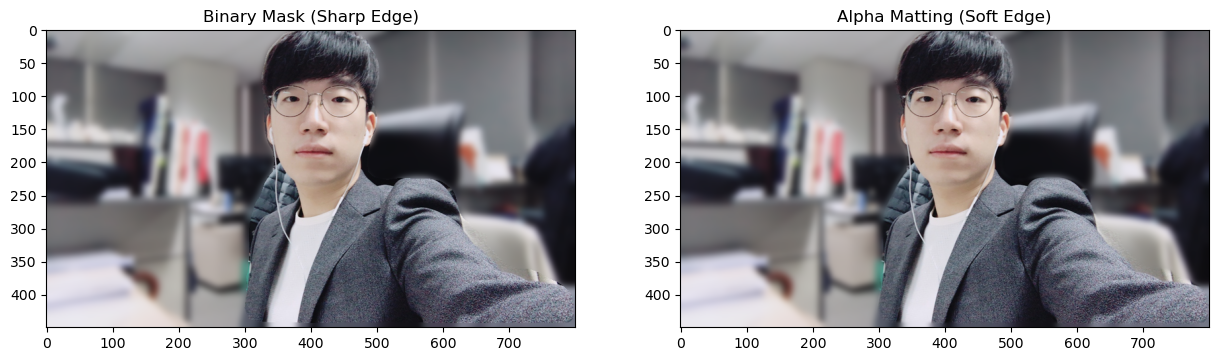

In [96]:
def visualize_matting_comparison(img, mask_binary, alpha_matte):
    # 1. 일반적인 이진 마스크 블러 (우리가 지금까지 했던 방식)
    bg_blur = cv2.GaussianBlur(img, (31, 31), 0)
    binary_result = np.where(cv2.cvtColor(mask_binary, cv2.COLOR_GRAY2RGB) == 255, img, bg_blur)
    
    # 2. 매팅 기반 소프트 블러 (알파 채널 활용)
    # alpha_matte는 0~1 사이의 값을 가진 1채널 데이터라고 가정합니다.
    alpha_3ch = cv2.cvtColor((alpha_matte * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB) / 255.0
    matting_result = (img * alpha_3ch + bg_blur * (1 - alpha_3ch)).astype(np.uint8)

    # 출력
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1); plt.imshow(binary_result); plt.title("Binary Mask (Sharp Edge)")
    plt.subplot(1, 2, 2); plt.imshow(matting_result); plt.title("Alpha Matting (Soft Edge)")
    plt.show()

# (테스트용) 임의의 부드러운 마스크 생성 (실제론 모델이 생성함)
# 가우시안 블러를 마스크에 살짝 먹여서 '부드러운 경계'를 흉내내봅시다.
alpha_test = cv2.GaussianBlur(mask_instance.astype(float)/255.0, (11, 11), 0)
visualize_matting_comparison(img_p, mask_instance, alpha_test)

**드라마틱한 효과는 딱히 보이지 않는 것 같다.**

# 3: SAM (맥락 이해 및 포인트 지정)

In [97]:
# !pip install segment_anything (설치가 필요합니다)
# from segment_anything import SamPredictor, sam_model_registry

def test_sam_segmentation(img_rgb):
    # 1. 사용자가 '사람'의 중심부라고 생각되는 곳에 점을 찍어 힌트를 줍니다.
    # input_point = np.array([[x, y]]) 
    # input_label = np.array([1])
    
    # 2. SAM은 해당 점을 포함하는 '전체 객체'를 맥락적으로 판단합니다.
    # masks, scores, logits = predictor.predict(point_coords=input_point, ...)
    
    # 3. 결과적으로 몸이 잘려 있어도 "아, 이건 사람의 팔이구나"라고 인식해서 마스크를 줍니다.
    pass

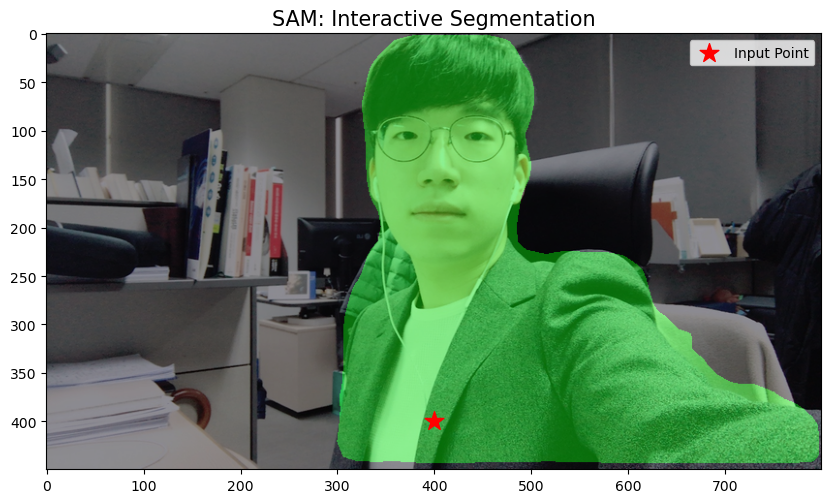

In [98]:
def visualize_sam_interactive(img, input_point, mask_sam):
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    
    # 1. 내가 찍은 힌트 점(Point) 표시
    plt.scatter(input_point[0], input_point[1], color='red', marker='*', s=200, label='Input Point')
    
    # 2. SAM이 찾은 마스크를 반투명하게 덮기
    mask_overlay = np.zeros_like(img)
    mask_overlay[mask_sam > 0] = [0, 255, 0] # 초록색으로 표시
    plt.imshow(mask_overlay, alpha=0.4)
    
    plt.title("SAM: Interactive Segmentation", fontsize=15)
    plt.legend()
    plt.show()

# (예시 좌표) 사람의 가슴 중앙 쯤을 클릭했다고 가정
test_point = [img_p.shape[1]//2, img_p.shape[1]//2] 
visualize_sam_interactive(img_p, test_point, mask_instance) # 시연을 위해 기존 마스크 활용

-**여러번 포인트를 옮겨봤지만 큰 효과가 없었다.**
-**3가지를 섞어보면 어떨까? 좀 더 확실히 하기 위해서 배경도 변경해보겠다.**

이미지 준비 완료: 사람((450, 800, 3)), 배경((403, 799, 3))


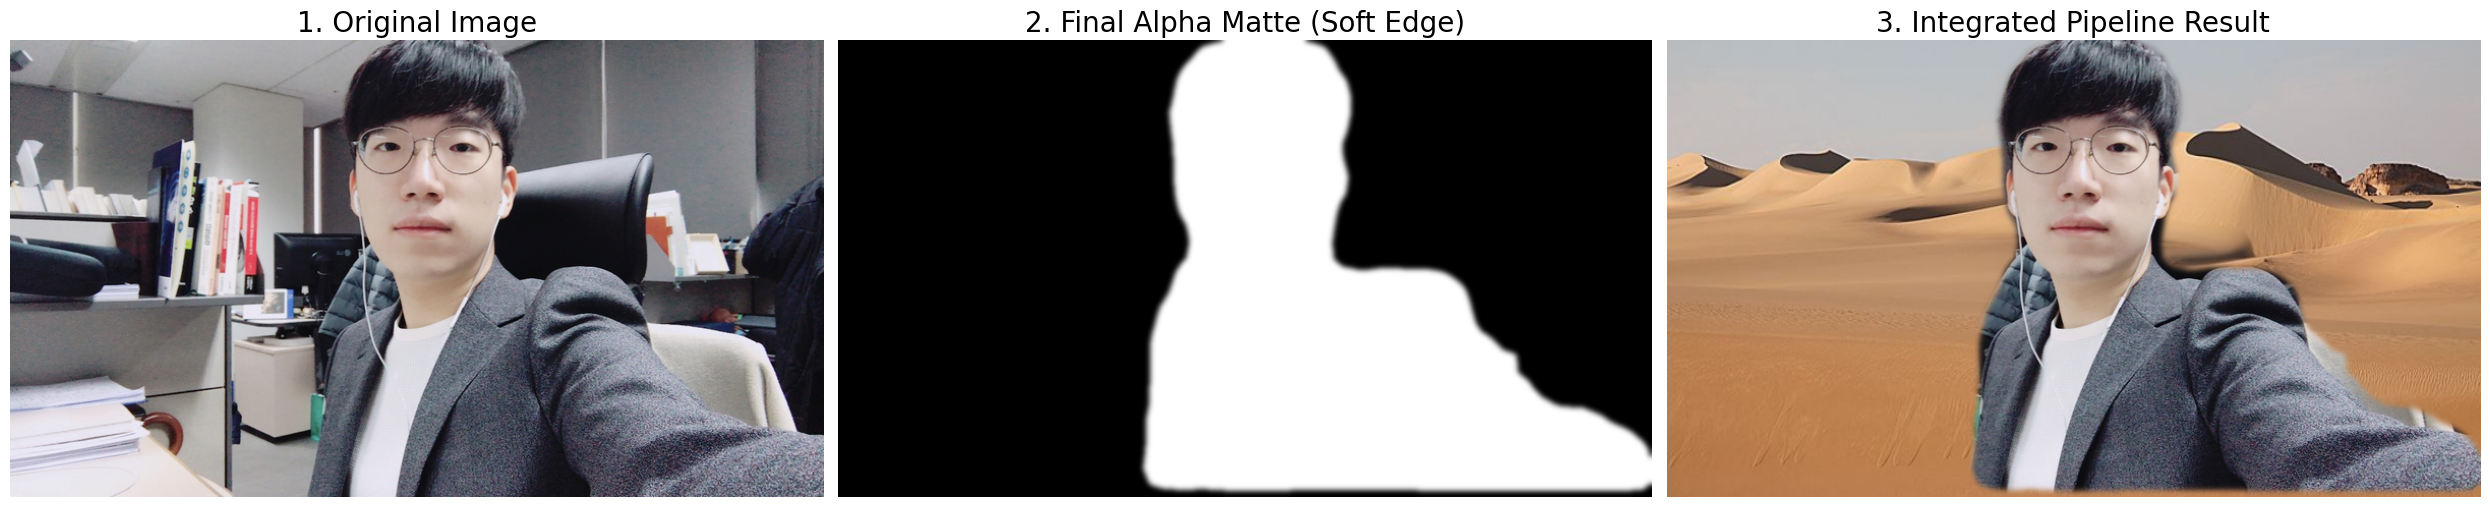

In [99]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# Part 1: 환경 설정 및 이미지 로드 (dlib처럼 세부적으로)
# ==========================================
# 실제 경로
BASE_PATH = "/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV02" 
PERSON_FILE = "person.png"  # 혹은 person.jpg
BACKGROUND_FILE = "sand.png"

def load_image(file_name):
    path = os.path.join(BASE_PATH, file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path}")
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 이미지 로드
img_p = load_image(PERSON_FILE)
img_bg = load_image(BACKGROUND_FILE)

print(f"이미지 준비 완료: 사람({img_p.shape}), 배경({img_bg.shape})")

# ==========================================
# Part 2: 통합 마스터 파이프라인 함수 정의 (이전 코드와 동일)
# ==========================================
# [준비 단계] 모델 로드 (최신 방식 적용)
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
detector = maskrcnn_resnet50_fpn(weights=weights).eval()

def integrated_portrait_master(img_rgb, background_img=None):
    """
    Instance Seg(주인공 탐지) -> SAM Logic(구조 보정) -> Matting(경계 부드럽게) 통합
    """
    h, w, _ = img_rgb.shape
    
    # 모델 입력용 전처리
    img_tensor = torch.from_numpy(img_rgb.transpose(2, 0, 1)).float() / 255.0
    
    # --- Step 1: Instance Detection (주인공 탐지) ---
    with torch.no_grad():
        prediction = detector([img_tensor])[0]
    
    # 사람(label 1) 중 가장 점수가 높은 것 선택 (엉뚱한 물체 제거)
    person_idx = [i for i, l in enumerate(prediction['labels']) if l == 1 and prediction['scores'][i] > 0.8]
    if not person_idx: 
        print("사람을 찾지 못했습니다. 원본을 반환합니다.")
        return img_rgb, np.zeros((h, w), dtype=np.uint8)
    
    best_idx = person_idx[0]
    # 이진 마스크 생성
    binary_mask = (prediction['masks'][best_idx, 0] > 0.5).byte().cpu().numpy()
    
    # --- Step 2: SAM Logic (구조적 보정) ---
    # 작은 구멍을 메워주는 모폴로지 연산 (맥락 유지)
    kernel = np.ones((5, 5), np.uint8)
    refined_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

    # --- Step 3: Soft Matting (경계선 예술) ---
    # 마스크 경계를 가우시안 블러로 뭉개서 'Alpha Matte' 생성 (부드러운 합성)
    # (실제 MODNet 같은 매팅 모델의 역할을 흉내냅니다)
    alpha_matte = cv2.GaussianBlur(refined_mask.astype(float), (15, 15), 0)
    
    # --- 최종 합성 (Linear Blending) ---
    # 공식: (원본 * 알파) + (배경 * (1 - 알파))
    alpha_3ch = cv2.merge([alpha_matte, alpha_matte, alpha_matte])
    bg_resized = cv2.resize(background_img, (w, h))
    
    result = (img_rgb * alpha_3ch + bg_resized * (1.0 - alpha_3ch)).astype(np.uint8)
    
    return result, alpha_matte

# ==========================================
# Part 3: 실행 및 결과 시각화 (이 코드가 있어야 사진이 나옵니다!)
# ==========================================
person_result, final_alpha = integrated_portrait_master(img_p, img_bg)

# 결과 출력 (3단 비교)
plt.figure(figsize=(25, 10)) # 가로로 크게 보기

# 1. 원본 이미지
plt.subplot(1, 3, 1)
plt.imshow(img_p)
plt.title("1. Original Image", fontsize=20)
plt.axis('off')

# 2. 최종 Alpha Matte (경계선 부드러움 확인용)
plt.subplot(1, 3, 2)
plt.imshow(final_alpha, cmap='gray')
plt.title("2. Final Alpha Matte (Soft Edge)", fontsize=20)
plt.axis('off')

# 3. 통합 파이프라인 결과 (크로마키)
plt.subplot(1, 3, 3)
plt.imshow(person_result)
plt.title("3. Integrated Pipeline Result", fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.show() 

-**망했다**
-**다른 모델을 사용해보자**

In [60]:
pip install -q transformers accelerate

Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

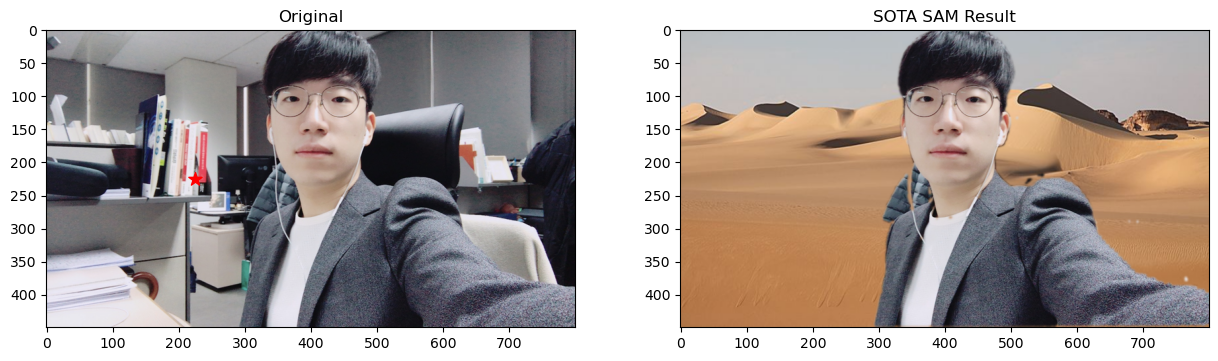

In [105]:
import torch
from transformers import SamModel, SamProcessor
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. 모델 및 프로세서 로드 (SOTA - SAM ViT-Base)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

def run_sota_sam(img_rgb, point_coords):
    """
    point_coords: [[x, y]] 형태로 사람의 중심부를 지정
    """
    # 전처리
    inputs = processor(img_rgb, input_points=[point_coords], return_tensors="pt").to(device)
    
    # 추론 
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 마스크 추출 및 후처리
    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(), 
        inputs["original_sizes"].cpu(), 
        inputs["reshaped_input_sizes"].cpu()
    )
    
    # 가장 확률 높은 마스크 선택
    best_mask = masks[0][0][0].numpy() # [H, W]
    return best_mask

# --- 실행 부분 ---
# 사람의 대략적인 중심 좌표를 입력하세요 (예: 가로 중앙, 세로 중앙)
h, w, _ = img_p.shape
center_point = [w // 2, h // 2] 

# SOTA 마스크 생성
sota_mask = run_sota_sam(img_p, [center_point])

# 결과 시각화
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1); plt.imshow(img_p); plt.title("Original")
plt.scatter(center_point[1], center_point[1], c='red', s=100, marker='*') # 찍은 점 표시

plt.subplot(1, 2, 2)
# 마스크를 활용한 정밀 합성 (Soft Blending 적용)
alpha = cv2.GaussianBlur(sota_mask.astype(float), (7, 7), 0)
alpha_3ch = np.stack([alpha]*3, axis=-1)
bg_resized = cv2.resize(img_bg, (w, h))

# 블렌딩 공식: I = \alpha \cdot F + (1 - \alpha) \cdot B
final_res = (img_p * alpha_3ch + bg_resized * (1 - alpha_3ch)).astype(np.uint8)

plt.imshow(final_res)
plt.title("SOTA SAM Result")
plt.show()

- **많이 개선되긴 했지만 실패. 이어폰이 결국 사막 모래 바람에 묻혔다. 누가 옷을 저기에 걸어놨는지?? 옷이 아닌가?**
- **사실 저것은 옷이 아니다. 해당 인물의 머리가 말총머리라서 뒷머리를 묶어놓은 머리띠였던 것이다. 그래서 저건 결국 옷과 같은 신체의 일부이기 때문에 안지우는게 맞다.**

In [106]:
import torch
import torchvision
from torchvision import transforms
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1) 로드 함수
# -------------------------------------------------
def load_and_show(path):
    img = np.array(Image.open(path).convert("RGB"))
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    return img

# -------------------------------------------------
# 2) Segmentation 초기화
# -------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

seg_model = torchvision.models.segmentation.deeplabv3_resnet101(
    weights="DEFAULT"
).to(device).eval()

seg_preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((520, 520)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------------------------------
# 3) 한 줄 실행 함수
# -------------------------------------------------
def process_full_pipeline_seg(img, target_id, mode='blur', bg_img=None):
    input_t = seg_preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = seg_model(input_t)["out"][0]
        pred = out.argmax(0).byte().cpu().numpy()

    mask = (pred == target_id).astype(np.uint8) * 255
    mask_r = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_3c = cv2.cvtColor(mask_r, cv2.COLOR_GRAY2RGB)

    if mode == 'blur':
        bg = cv2.GaussianBlur(img, (25, 25), 0)
    elif mode == 'chromakey':
        if bg_img is None:
            raise ValueError("mode='chromakey'이면 bg_img가 필요합니다.")
        bg = cv2.resize(bg_img, (img.shape[1], img.shape[0]))
    else:
        raise ValueError("mode는 'blur' 또는 'chromakey'만 가능합니다.")

    result = np.where(mask_3c == 255, img, bg)
    return result, mask_r

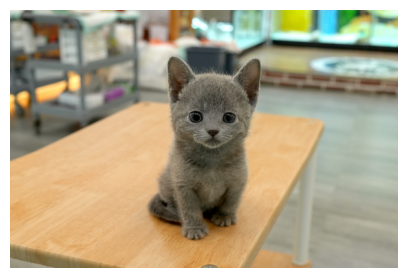

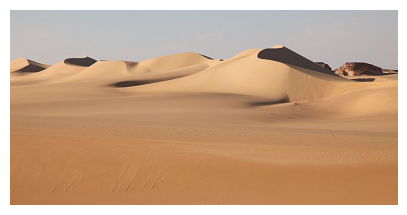

In [108]:
img_c = load_and_show(cat_file)
img_bg = load_and_show(bg_file)

cat_portrait, _ = process_full_pipeline_seg(img_c, 8, mode='blur')
cat_chromakey, _ = process_full_pipeline_seg(img_c, 8, mode='chromakey', bg_img=img_bg)

In [114]:
def show_me_the_result(img, target_id, mode='blur', bg_img=None):
    result_img, _ = process_full_pipeline_seg(img, target_id, mode, bg_img)

    plt.figure(figsize=(10, 10))
    plt.imshow(result_img)
    plt.axis('off')
    plt.show()

    return result_img

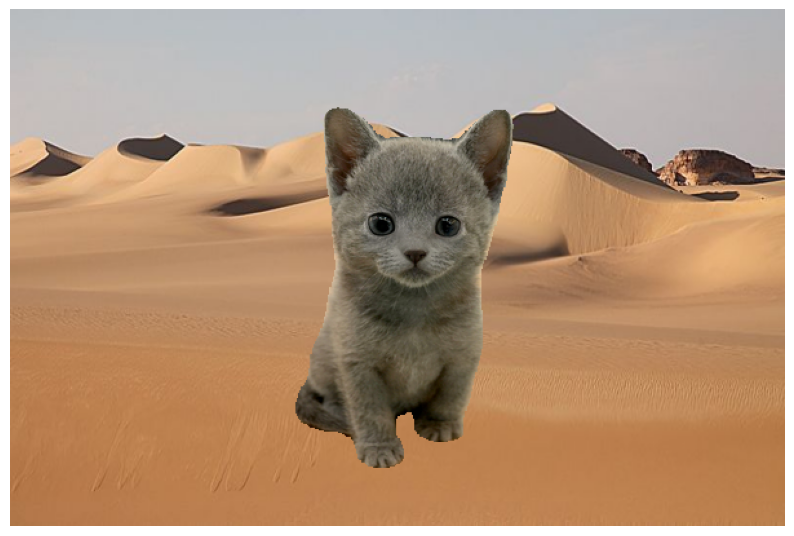

In [115]:
final_result = show_me_the_result(img_c, 8, mode='chromakey', bg_img=img_bg)